# Tutorial: Orchestrator Agentic Pattern with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: jupyter notebook password to generate onetime password for secure access
- To Run at root directory of the repo: jupyter notebook --allow-root  --port 9999 --ip=0.0.0.0
- To Clear Outputs: Use jupyter nbconvert --clear-output --inplace 5_Orchestrator_Pattern.ipynb

This walkthrough demonstrates how to build and orchestrate an `Orchestrator agentic pipeline` using the **AgentGrid SDKs**. We focus on the **Universal Marketing Campaign** flow, where an orchestrator dynamically plans and executes localized marketing strategies across multiple regions.

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama, etc.) without changing your agent's core logic. The models which are hosted in AIOS as blocks or 3rd party models like OpenAI/Gemini/etc also can be accessed via the `agents_llm` library. As we will use `DSpy Library` for Agentic Programming, we have created a custom class to wrap the `agents_llm` library and provide a more user-friendly interface for model inference: `AIOS_DSPy_LMs` custom class.

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent.

### Core Data Structures
- **`AgentTask`**: Contains the `job_data` (payload) and metadata.
- **`AgentResult`**: Packages the output or error state.

### The `Context` Object
Every agent is initialized with a `Context`, providing communication handles:
1. **`p2p_manager`**: Synchronous or asynchronous peer-to-peer messaging. The Agent P2P Module enables decentralized, real-time communication between AI agents using WebSocket and HTTP. It supports direct messaging, API calls, file transfer, and remote task execution, making it ideal for distributed multi-agent coordination.
2. **`delegator`**: Offloading tasks to specialized workers (centralized orchestration).
3. **`direct`**: Submitting tasks directly to others without central brokers.

### Class Structure

In [ ]:
# sample_agent.py
import logging
import uuid
from typing import List, Optional

from core.agent_executor import AgentTask, AgentResult
from core.main import main
from core.agent_executor import Context

log = logging.getLogger(__name__)


class SampleAgent:

    def __init__(self, subject, context: Context) -> None:
        self.subject = subject
        self.context = context

    def get_muxer(self):
        return None

    def on_preprocess(self, task: AgentTask) -> Optional[List[AgentTask]]:

        text = task.job_data.get("text")
        if not text:
            log.warning(
                "Task %s has no 'text' in job_data, skipping.", task.task_id)
            return None

        return [task]

    def on_data(self, task: AgentTask) -> AgentResult:

        try:
            text = task.job_data["text"]
            out = text.upper()
            # Implementation logic here...
            return AgentResult(
                task_id=task.task_id,
                job_output={"text": out},
                is_error=False,
            )

        except Exception as e:
            log.exception("Error processing task %s: %s", task.task_id, e)
            return AgentResult(
                task_id=task.task_id,
                is_error=True,
                error_data={"stage": "on_data", "message": str(e)},
            )


main(SampleAgent)


### Workflow Summary
1. Define the agent's logic using the **Base Class Template** and **DSPy/LLMs**.
2. Use **`Context`** (P2P, Delegator, or Direct) to orchestrate data across agents.
3. Containerize the agent (Docker) and register it in the **AgentGrid Registry**.
4. Deploy using the **`agents_deployer`** to Kubernetes.
5. Execute requests via the **Orchestrator** to trigger the dynamic pipeline.

---

## 3. Case Study: Universal Marketing Campaign with Orchestrator Pattern

The **Orchestrator Pattern** uses a central agent to break down complex goals into a structured set of tasks executed by workers. Unlike a static chain, the orchestrator can dynamically adapt the pipeline based on the goals and available agent capabilities.

### Marketing Pipeline Stages:
1. **Strategic Planning**: The **Orchestrator** analyzes the product and target markets to design custom pipelines.
2. **Content Generation**: The **Content Creator** produces localized campaign copy.
3. **Visual Creation**: The **Image Generator** uses Google Imagen (or similar) to create assets and stores them in **MinIO**.
4. **Brand Review (Agentic Retry)**: The **Image Reviewer** evaluates the visual alignment. If the score is low, it triggers a retry of the Image Generator with specific feedback.
5. **Social Strategy**: The **Social Media Campaigner** defines target audiences and distribution channels.

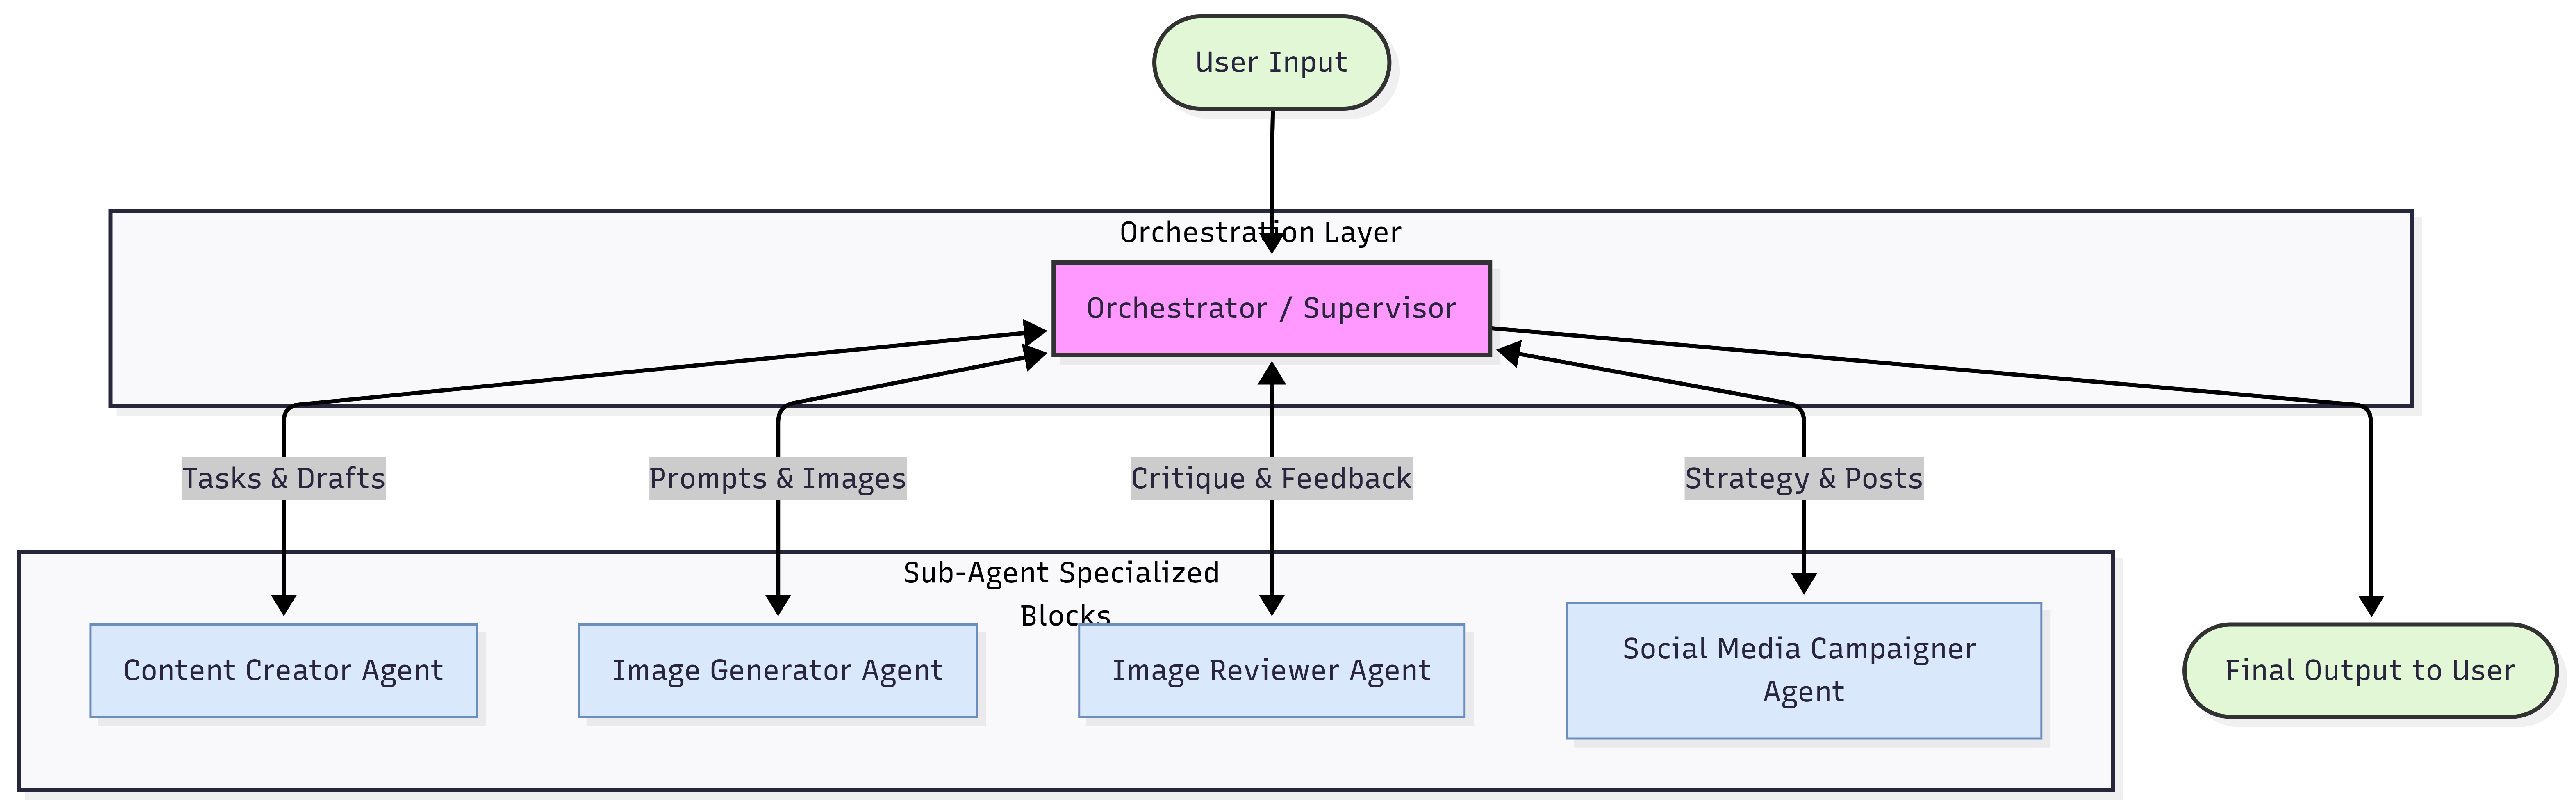

### Agent Roles & Constraints

| Agent | Role | Capabilities | Path |
| :--- | :--- | :--- | :--- |
| **Orchestrator Agent** | Planner | Decomposes product descriptions into regional campaigns and sequences agents. | `agent_codes/agent_marketing_orchestrator.py` |
| **Content Creator** | Localizer | Transforms core descriptions into culturally idioms for specific regions. | `agent_codes/agent_marketing_content_creator.py` |
| **Image Generator** | Visual Artist | Generates creative assets from descriptions and uploads to MinIO. | `agent_codes/agent_marketing_image_generator.py` |
| **Image Reviewer** | Consultant | Audits images for cultural alignment and triggers retries if quality threshold (e.g., Score < 8) is not met. | `agent_codes/agent_marketing_image_reviewer.py` |
| **Social Campaigner** | Strategist | Defines demographics, platform-specific engagement, and optimal posting schedules. | `agent_codes/agent_marketing_social_media_campaigner.py` |


---

## 4. Execution Pipeline

1. **Agent Registration**: Register all RFC agents in the cluster.
   - Script: [register-agents.sh](../../agents_registration/5_orchestrator_marketing_agents/register-agents.sh)
2. **Deployment**: Spin up containers for the RFC evaluation flow.
   - Script: [deploy-agents.sh](../../agents_registration/5_orchestrator_marketing_agents/deploy-agents.sh)
3. **Triggering the Flow**: Send the initial RFC text to the **Summarizer**.
   - Script: [inference_request.sh](../../agents_registration/5_orchestrator_marketing_agents/inference_request.sh)
4. **All in One**: Run [all.bash](../../agents_registration/5_orchestrator_marketing_agents/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash to setup the Orchestrator Flow

In [ ]:
%%bash
cd ../../agents_registration/5_orchestrator_marketing_agents
bash all.bash

#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

##### Check Containers in a Pod

In [ ]:
kubectl get pod -n agents <PODNAME> -o jsonpath='{.spec.containers[*].name}'

##### Executor Containers
- executor: ratelimiting, config management, load balancing, autoscaling etc
- Scouter: responsible for scouting jobs in Job Exchange
 
* User can define the policy for above 

#### Trigger the First agent (Orchestrator)

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/5_orchestrator_marketing_agents
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
cd ../../agents_registration/5_orchestrator_marketing_agents
bash remove-agents.sh

---

## 5. Conclusion

The **Orchestrator Pattern** is essential for multi-stage workflows requiring complex reasoning and coordination. By combining the **AgentGrid SDKs** with dynamic planning and agentic retries, we can build robust, self-correcting AI systems for sophisticated tasks like global marketing orchestration.